# Analysis of the Welltory COVID-19 and Wearables Open Data Research

## Understanding our data and the features

Link to dataset : https://github.com/Welltory/hrv-covid19/tree/master#

The dataset was created by tracking the progression and recovery of participants infected by the covid19 virus. Various factors were measured for this purpose including the heart rate variability, activity data using wearables like Apple watches and finally some physcial and health assessments. 

## Data Context and Sampling 

Population: Volunteer participants using the Welltory app and connected wearables (e.g., Apple Watch, smartphone PPG).

### Data Sources:

Wearables & smartphone sensors, Self-reports,Environmental data, Demographics

### Data Sampling

Sampling Period: Unsure, there are periods before covid19 was reported.

Sample Size: Includes thousands of measurements, but coverage per participant varies. Not every participant provided all data types (missingness is expected).

### Bias Considerations:

Participants are self-selected Welltory users hence not representative of the general population.

Device type and usage frequency may introduce measurement differences.

Self-reported symptoms and mood are subjective and may include recall bias.

In [36]:
# Imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the files
d_participants = pd.read_csv("/Users/mrinalgoel/bootcamp/aipi510-fall25/data/week4/participants.csv")
d_wearables = pd.read_csv("/Users/mrinalgoel/bootcamp/aipi510-fall25/data/week4/wearables.csv")

# EDA on the participants file for symptom Onset periods

I would like to understand which were the peak months where participants reported the symptoms onset for covid19 and if this aligns with the trends reported in the news.

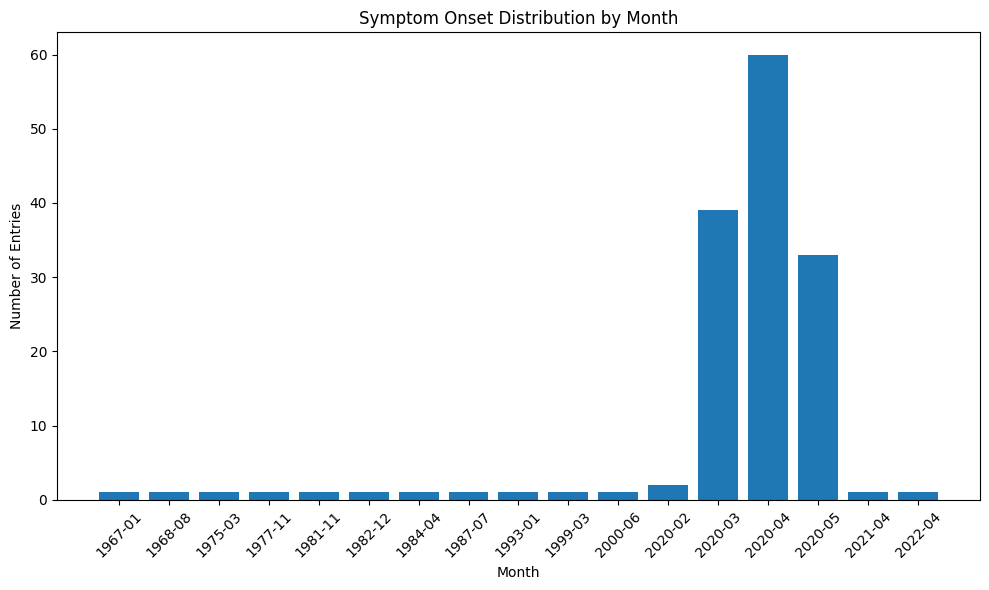

In [37]:
# Ensure the column is parsed as datetime
d_participants['symptoms_onset'] = pd.to_datetime(d_participants['symptoms_onset'])

# Extract month and year for grouping
d_participants['onset_month'] = d_participants['symptoms_onset'].dt.to_period('M')

# Count number of users per month
distribution = d_participants.groupby('onset_month')['user_code'].nunique()

# Bar plot
plt.figure(figsize=(10,6))
plt.bar(distribution.index.astype(str), distribution.values)
plt.title("Symptom Onset Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Entries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A majority of the participants reported symptom onset in the months of March, April and May of 2020. March of 2020 is when WHO declared Covid19 a gloabl pandemic : https://pmc.ncbi.nlm.nih.gov/articles/PMC7569573/#:~:text=The%20World%20Health%20Organization%20(WHO,WHO%20Director%2DGeneral%2C%20Dr.). Ironically, there are people that have reported covid19 symptoms before 2019, this would make me question the accuracy of this dataset.

# EDA on the participants file to check which counteries the participants that saw symptoms onset in march, April and May of 2022 are from.

country
Russia            51
United States     39
United Kingdom    11
Brazil             6
Belarus            5
Ukraine            4
France             3
Finland            2
Hungary            1
Indonesia          1
Isle of Man        1
Germany            1
Norway             1
Spain              1
Sweden             1
Switzerland        1
Netherlands        1
Name: user_code, dtype: int64


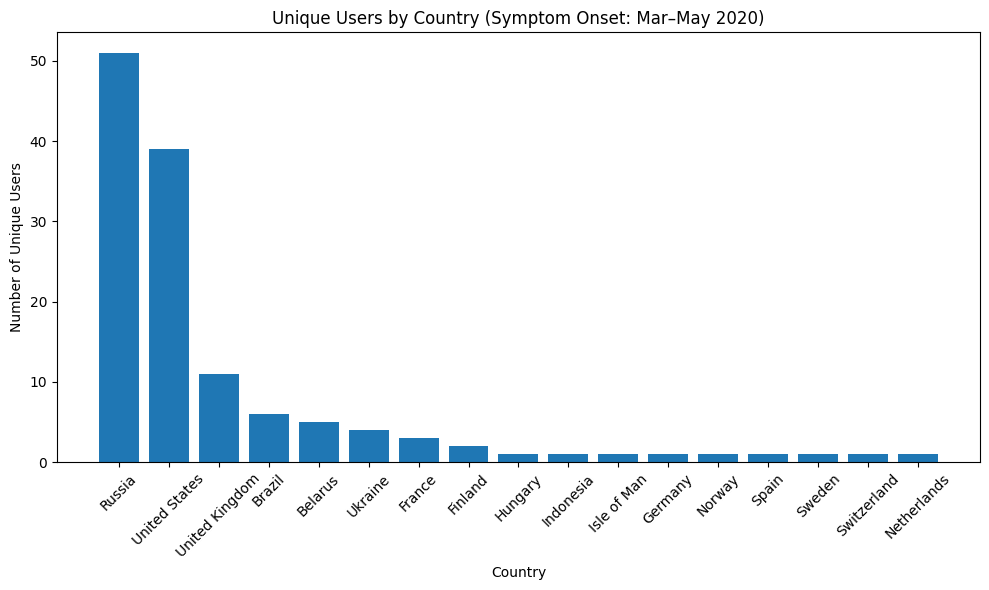

In [38]:
# Define the months we care about
target_months = ['2020-03', '2020-04', '2020-05']

# Filter the dataframe
filtered = d_participants[d_participants['onset_month'].astype(str).isin(target_months)]

# Count unique users by country
distribution_country = filtered.groupby('country')['user_code'].nunique().sort_values(ascending=False)

print(distribution_country)

# Plot
plt.figure(figsize=(10,6))
plt.bar(distribution_country.index, distribution_country.values)
plt.title("Unique Users by Country (Symptom Onset: Mar–May 2020)")
plt.xlabel("Country")
plt.ylabel("Number of Unique Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This data is accurate with the information about the first wave in the top 3 counteries - All three countries entered their first wave between March and May 2020.

The United States and UK peaked in April 2020, while Russia peaked a bit later, in May 2020.

# Now let us do an EDA on the Wearables data

I want to check if the average steps of a user dropped after they reported seeing symptoms of covid19. Here, we will create a new feature and call it `percentage_change_step_counts` which will talk about what was the change in step count of an individual post reporting symptoms onset.

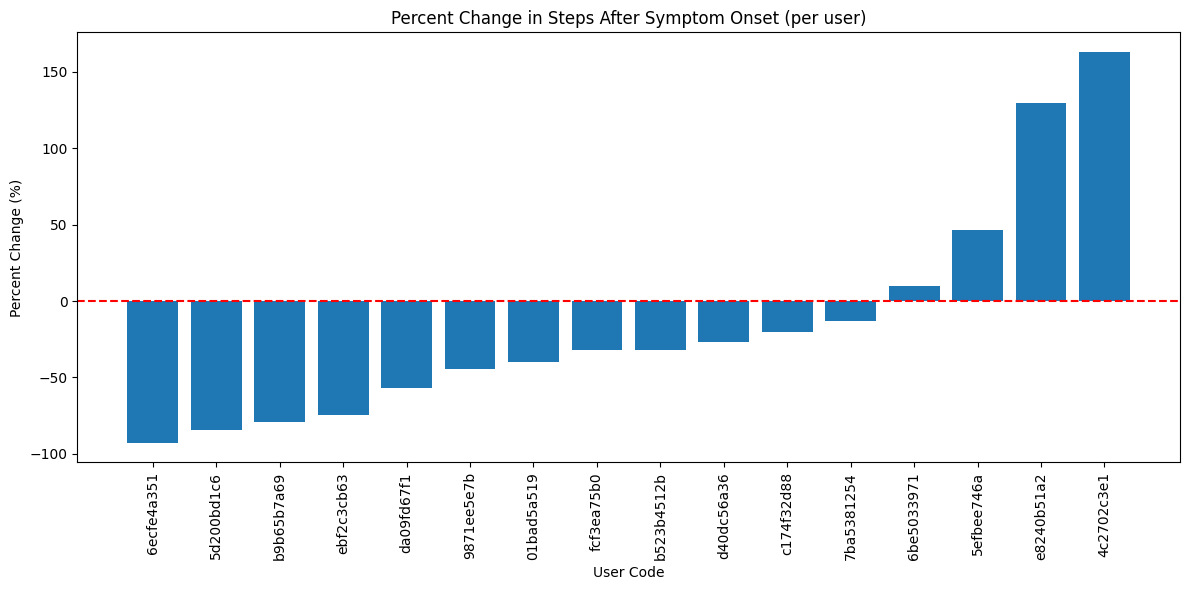

In [39]:

# Convert dates
d_wearables['day'] = pd.to_datetime(d_wearables['day'], errors='coerce')
d_participants['symptoms_onset'] = pd.to_datetime(d_participants['symptoms_onset'], errors='coerce')

# Merge on user_code
merged = d_wearables.merge(d_participants[['user_code','symptoms_onset']], on='user_code', how='inner')

# Flag before/after onset
merged['period'] = merged.apply(
    lambda x: 'before' if x['day'] < x['symptoms_onset'] else 'after',
    axis=1
)

# Compute average steps before vs after
steps_comparison = merged.groupby(['user_code','period'])['steps_count'].mean().unstack()

# Add drop column
steps_comparison['drop_in_steps'] = steps_comparison['after'] - steps_comparison['before']
steps_comparison['percent_change_step_counts'] = (
    (steps_comparison['after'] - steps_comparison['before']) / steps_comparison['before']
) * 100

# Drop NaN (users missing data before or after)
steps_comparison_clean = steps_comparison.dropna(subset=['percent_change_step_counts'])

# Sort by % change
steps_comparison_clean = steps_comparison_clean.sort_values('percent_change_step_counts')

# Plot
plt.figure(figsize=(12,6))
plt.bar(steps_comparison_clean.index, steps_comparison_clean['percent_change_step_counts'])
plt.axhline(0, color='red', linestyle='--')
plt.title("Percent Change in Steps After Symptom Onset (per user)")
plt.xlabel("User Code")
plt.ylabel("Percent Change (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


There are a few users (4) whose steps averaged increased (even 150% times!) post reporting symptom onset. Though this data is not sufficient but seems like a majority of the individuals had a decrease in their steps averaged post symptom onset.

# Thoughts and Rationale

In this short EDA, I was trying to establish if there was any relation between the covid19 pandemic spreading more violently in the transition months of March, April and May. Was there any seasonal effect? I was also trying to check the data's correctness. Next, I was trying to relate symptom onset with decreased activity using the steps count. 